In [1]:
# ==================================================
# Import Libraries
# ==================================================

from pathlib import Path
import sys


# Project root
PROJECT_ROOT = Path.cwd().parents[1]

sys.path.insert(
    0,
    str(PROJECT_ROOT)
)


# Data
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt


# ML
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

# MLflow
from src.mlflow.tracking import MLflowTracker
from src.mlflow.utils import classification_metrics

d:\Subject\CV2026\Market Risk Classification\market-risk-classification\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==================================================
# Load Data
# ==================================================

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "BTCUSDT"
    / "BTCUSDT_1m_target.csv"
)


df = pd.read_csv(
    DATA_PATH
)


df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,target
0,2025-01-01 00:00:00,93576.00,93610.93,93537.50,93610.93,8.21827,2025-01-01 00:00:59.999,7.689788e+05,2631,3.95157,369757.326529,0,1
1,2025-01-01 00:01:00,93610.93,93652.00,93606.20,93652.00,12.14029,2025-01-01 00:01:59.999,1.136551e+06,1273,4.08887,382791.500172,0,1
2,2025-01-01 00:02:00,93652.00,93702.15,93635.98,93702.15,11.60597,2025-01-01 00:02:59.999,1.087101e+06,1095,5.86840,549682.868570,0,0
3,2025-01-01 00:03:00,93702.14,93702.15,93654.48,93677.98,8.72958,2025-01-01 00:03:59.999,8.177203e+05,1461,2.48203,232486.113080,0,0
4,2025-01-01 00:04:00,93677.98,93677.99,93659.92,93661.20,5.24749,2025-01-01 00:04:59.999,4.915570e+05,988,0.48880,45786.251963,0,1


In [3]:
# ==================================================
# Data Information
# ==================================================

print(df.shape)

df.info()

(20160, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20160 entries, 0 to 20159
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   open_time               20160 non-null  object 
 1   open                    20160 non-null  float64
 2   high                    20160 non-null  float64
 3   low                     20160 non-null  float64
 4   close                   20160 non-null  float64
 5   volume                  20160 non-null  float64
 6   close_time              20160 non-null  object 
 7   quote_asset_volume      20160 non-null  float64
 8   number_of_trades        20160 non-null  int64  
 9   taker_buy_base_volume   20160 non-null  float64
 10  taker_buy_quote_volume  20160 non-null  float64
 11  ignore                  20160 non-null  int64  
 12  target                  20160 non-null  int64  
dtypes: float64(8), int64(3), object(2)
memory usage: 2.0+ MB


In [4]:
# ==================================================
# Drop Unnecessary Columns
# ==================================================

df = df.drop(
    columns=[
        "open_time",
        "close_time",
        "ignore"
    ]
)


df.head()

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,target
0,93576.00,93610.93,93537.50,93610.93,8.21827,7.689788e+05,2631,3.95157,369757.326529,1
1,93610.93,93652.00,93606.20,93652.00,12.14029,1.136551e+06,1273,4.08887,382791.500172,1
2,93652.00,93702.15,93635.98,93702.15,11.60597,1.087101e+06,1095,5.86840,549682.868570,0
3,93702.14,93702.15,93654.48,93677.98,8.72958,8.177203e+05,1461,2.48203,232486.113080,0
4,93677.98,93677.99,93659.92,93661.20,5.24749,4.915570e+05,988,0.48880,45786.251963,1


In [5]:
# ==================================================
# Missing Values
# ==================================================

df.isnull().sum()

open                      0
high                      0
low                       0
close                     0
volume                    0
quote_asset_volume        0
number_of_trades          0
taker_buy_base_volume     0
taker_buy_quote_volume    0
target                    0
dtype: int64

In [6]:
# ==================================================
# Feature / Target
# ==================================================

TARGET = "target"


FEATURES = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume",
]


X = df[FEATURES].values

y = df[TARGET].values


print(X.shape)
print(y.shape)

(20160, 9)
(20160,)


In [7]:
# ==================================================
# Create Sequence
# ==================================================

TIME_STEPS = 60


def create_sequences(
    X,
    y,
    time_steps
):

    Xs = []
    ys = []

    for i in range(
        len(X) - time_steps
    ):

        Xs.append(
            X[i:i + time_steps]
        )

        ys.append(
            y[i + time_steps]
        )

    return np.array(Xs), np.array(ys)



X_seq, y_seq = create_sequences(
    X,
    y,
    TIME_STEPS
)


print(X_seq.shape)
print(y_seq.shape)

(20100, 60, 9)
(20100,)


In [8]:
# ==================================================
# Train Test Split
# ==================================================

split_index = int(
    len(X_seq) * 0.8
)


X_train = X_seq[:split_index]
X_test = X_seq[split_index:]


y_train = y_seq[:split_index]
y_test = y_seq[split_index:]


print(X_train.shape)
print(X_test.shape)

(16080, 60, 9)
(4020, 60, 9)


In [9]:
# ==================================================
# Feature Scaling
# ==================================================

scaler = StandardScaler()


# reshape để scale
n_train_samples, time_steps, n_features = X_train.shape


X_train_scaled = scaler.fit_transform(
    X_train.reshape(
        -1,
        n_features
    )
)


X_test_scaled = scaler.transform(
    X_test.reshape(
        -1,
        n_features
    )
)


# reshape lại cho LSTM

X_train_scaled = X_train_scaled.reshape(
    n_train_samples,
    time_steps,
    n_features
)


X_test_scaled = X_test_scaled.reshape(
    X_test.shape[0],
    time_steps,
    n_features
)


print(X_train_scaled.shape)
print(X_test_scaled.shape)

(16080, 60, 9)
(4020, 60, 9)


In [10]:
# ==================================================
# Build LSTM Model
# ==================================================

model = Sequential(
    [
        LSTM(
            units=64,
            input_shape=(
                TIME_STEPS,
                len(FEATURES)
            ),
            return_sequences=False
        ),

        Dropout(
            0.2
        ),


        Dense(
            32,
            activation="relu"
        ),


        Dropout(
            0.2
        ),


        Dense(
            1,
            activation="sigmoid"
        )
    ]
)


model.summary()

d:\Subject\CV2026\Market Risk Classification\market-risk-classification\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ==================================================
# Compile Model
# ==================================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)

In [12]:
# ==================================================
# Initialize MLflow Tracker
# ==================================================

tracker = MLflowTracker()

In [13]:
# ==================================================
# Train LSTM + MLflow
# ==================================================

with tracker.start_run(
    run_name="LSTM Baseline"
):


    history = model.fit(
        X_train_scaled,
        y_train,

        validation_data=(
            X_test_scaled,
            y_test
        ),

        epochs=20,
        batch_size=64,

        verbose=1
    )


    # Prediction

    y_prob = model.predict(
        X_test_scaled
    )


    y_pred = (
        y_prob > 0.5
    ).astype(int).reshape(-1)



    # Metrics

    metrics = classification_metrics(
        y_test,
        y_pred,
        y_prob.reshape(-1)
    )


    # ============================
    # Log MLflow
    # ============================

    tracker.log_params(
        {
            "model": "LSTM",
            "time_steps": TIME_STEPS,
            "units": 64,
            "dropout": 0.2,
            "epochs": 20,
            "batch_size": 64,
            "optimizer": "adam"
        }
    )


    tracker.log_metrics(
        metrics
    )


    tracker.log_model(
        model
    )


    tracker.generate_summary()

Epoch 1/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5091 - loss: 0.6947 - val_accuracy: 0.5157 - val_loss: 0.6928
Epoch 2/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5177 - loss: 0.6926 - val_accuracy: 0.5117 - val_loss: 0.6924
Epoch 3/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5161 - loss: 0.6928 - val_accuracy: 0.5052 - val_loss: 0.6932
Epoch 4/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5163 - loss: 0.6922 - val_accuracy: 0.5157 - val_loss: 0.6927
Epoch 5/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5236 - loss: 0.6918 - val_accuracy: 0.5092 - val_loss: 0.6936
Epoch 6/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5183 - loss: 0.6921 - val_accuracy: 0.5174 - val_loss: 0.6925
Epoch 7/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.5127 - loss: 0.6919 - val_accuracy: 0.5132 - val_loss: 0.6928
Epoch 8/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.5203 - loss: 0.6919 - val_ac

2026/07/30 14:18:05 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MLflow training summary generated
Saved at: D:\Subject\CV2026\Market Risk Classification\market-risk-classification\artifacts\training_summary.txt


In [14]:
# ==================================================
# Evaluation
# ==================================================

metrics

{'accuracy': 0.5101990049751244,
 'precision': 0.49022346368715086,
 'recall': 0.3616692426584235,
 'f1_score': 0.4162466646901868,
 'roc_auc': 0.5092523825135881}

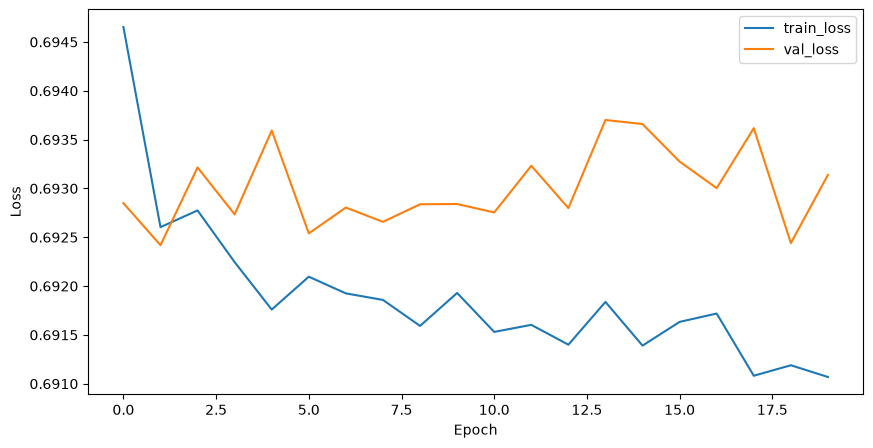

In [15]:
# ==================================================
# Training History
# ==================================================

plt.figure(
    figsize=(10,5)
)


plt.plot(
    history.history["loss"],
    label="train_loss"
)


plt.plot(
    history.history["val_loss"],
    label="val_loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)


plt.legend()

plt.show()

In [16]:
# ==================================================
# Check MLflow Runs
# ==================================================

import mlflow


experiment = mlflow.get_experiment_by_name(
    "Market Risk Classification"
)


runs = mlflow.search_runs(
    experiment_ids=[
        experiment.experiment_id
    ]
)


runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "metrics.accuracy",
        "metrics.f1",
        "metrics.roc_auc"
    ]
]

KeyError: "['metrics.f1'] not in index"